In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("../data/student_data.xls")
df.head()

,Timestamp,Email Address,Enter Your Name,Age,Gender,1.Enter Your Current Semester,2.Enter your attendance percentage,3.Enter your average internal marks,4.To what extent have you completed your assignments?,5.How do you participate in labs or seminar?,...,8.Do you take help from teachers or classmates?,"9.On average, how many hours of sleep do you get per day?","10. On average, how much time do you spend daily on mobile phones or social media?","11. On average, how much time do you spend traveling from your home/hostel to college each day?",12.How frequently do you participate in extracurricular activities ?,13.How motivated do you feel towards your studies on a daily basis?,"14. How much academic stress do you usually experience (due to exams, assignments, deadlines, etc.)?",15.How confident do you feel while preparing for and writing examinations?,16. How would you rate your overall academic performance in the last semester?,Enter your last semester CGPA
0,12/16/2025 12:30:26,akankshashetty68767@gmail.com,Akanksha,22,Female,3,86-95%,16-25,All,Always,...,Yes,5-6 hours,1-2 hours,15-30 minutes,Often,3,4,4,Average,9
1,12/16/2025 12:31:11,sowndaryabangera1@gmail.com,Bhagyashri,21,Female,3rd sem,76-85%,16-25,All,Always,...,Yes,6-7 hours,1-2 hours,15-30 minutes,Sometimes,3,4,4,Average,7.36
2,12/16/2025 12:33:59,harikiranap2003@gmail.com,Harikiran,22,Male,3,86-95%,16-25,Most,Always,...,Yes,5-6 hours,2-3 hours,more than 1 hour,Rarely,3,3,3,Average,7.2
3,12/16/2025 12:39:28,krithikas2304@gmail.com,Krithika,22,Female,3,95%+,16-25,All,Always,...,Yes,6-7 hours,2-3 hours,30-60 minutes,Sometimes,3,4,3,Average,8.48
4,12/16/2025 19:49:21,k6528725@gmail.com,Keerthana,22,Female,3,86-95%,25-30,All,Sometimes,...,Yes,6-7 hours,2-3 hours,30-60 minutes,Sometimes,4,4,4,High,9.5


In [5]:
df.columns = (
    df.columns
    .str.replace('\n', ' ', regex=False)
    .str.strip()
)

In [6]:
for col in df.columns:
    print(col)

Timestamp
Email Address
Enter Your Name
Age
Gender
1.Enter Your Current Semester
2.Enter your attendance percentage
3.Enter your average internal marks
4.To what extent have you completed your assignments?
5.How do you participate in labs or seminar?
6.How many hours do you study per day?
7.How do you ask doubts?
8.Do you take help from teachers or classmates?
9.On average, how many hours of sleep do you get per day?
10. On average, how much time do you spend daily on mobile phones or social media?
11. On average, how much time do you spend traveling from your home/hostel to college each day?
12.How frequently do you participate in extracurricular activities ?
13.How motivated do you feel towards your studies on a daily basis?
14. How much academic stress do you usually experience (due to exams, assignments, deadlines, etc.)?
15.How confident do you feel while preparing for and writing examinations?
16. How would you rate your overall academic performance in the last semester?
Enter yo

In [7]:
df.rename(columns={
    'Age': 'Age',
    'Gender': 'Gender',
    '1.Enter Your Current Semester': 'Semester',
    '2.Enter your attendance percentage': 'Attendance',
    '3.Enter your average internal marks': 'Internal_Marks',
    '4.To what extent have you completed your assignments?': 'Assignment_Completion',
    '5.How do you participate in labs or seminar?': 'Participation',
    '6.How many hours do you study per day ?': 'Study_Hours',
    '7.How do you ask doubts?': 'Doubt_Method',
    '8.Do you take help from teachers or classmates?': 'Teacher_Help',
    '9.On average, how many hours of sleep do you get per day?': 'Sleep_Hours',
    '10. On average, how much time do you spend daily on mobile phones or social media?': 'Mobile_Usage',
    '11. On average, how much time do you spend traveling from your home/hostel to college each day?': 'Travel_Time',
    '12.How frequently do you participate in extracurricular activities ?': 'Extracurricular',
    '13.How motivated do you feel towards your studies on a daily basis?': 'Motivation_Level',
    '14.How much academic stress do you usually experience (due to exams, assignments, deadlines, etc.)?': 'Stress_Level',
    '15.How confident do you feel while preparing for and writing examinations?': 'Confidence_Level',
    '16. How would you rate your overall academic performance in the last semester?': 'Performance_Level',
    'Enter your last semester CGPA': 'CGPA'
}, inplace=True)

In [8]:
df.drop(columns=['Timestamp', 'Name'], inplace=True, errors='ignore')

In [9]:
df.rename(columns={
    '14. How much academic stress do you usually experience (due to exams, assignments, deadlines, etc.)?': 
    'Stress_Level'
}, inplace=True)

In [10]:
df.rename(columns={
    '6.How many hours do you study per day?': 'Study_Hours'
}, inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Email Address          130 non-null    str  
 1   Enter Your Name        130 non-null    str  
 2   Age                    130 non-null    str  
 3   Gender                 130 non-null    str  
 4   Semester               130 non-null    str  
 5   Attendance             130 non-null    str  
 6   Internal_Marks         130 non-null    str  
 7   Assignment_Completion  127 non-null    str  
 8   Participation          130 non-null    str  
 9   Study_Hours            130 non-null    str  
 10  Doubt_Method           130 non-null    str  
 11  Teacher_Help           130 non-null    str  
 12  Sleep_Hours            130 non-null    str  
 13  Mobile_Usage           130 non-null    str  
 14  Travel_Time            130 non-null    str  
 15  Extracurricular        130 non-null    str  
 16  M

In [12]:
df.drop(columns=['Email Address'], inplace=True, errors='ignore')

In [13]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Enter Your Name        130 non-null    str  
 1   Age                    130 non-null    str  
 2   Gender                 130 non-null    str  
 3   Semester               130 non-null    str  
 4   Attendance             130 non-null    str  
 5   Internal_Marks         130 non-null    str  
 6   Assignment_Completion  127 non-null    str  
 7   Participation          130 non-null    str  
 8   Study_Hours            130 non-null    str  
 9   Doubt_Method           130 non-null    str  
 10  Teacher_Help           130 non-null    str  
 11  Sleep_Hours            130 non-null    str  
 12  Mobile_Usage           130 non-null    str  
 13  Travel_Time            130 non-null    str  
 14  Extracurricular        130 non-null    str  
 15  Motivation_Level       130 non-null    int64
 16  S

,Enter Your Name,Age,Gender,Semester,Attendance,Internal_Marks,Assignment_Completion,Participation,Study_Hours,Doubt_Method,Teacher_Help,Sleep_Hours,Mobile_Usage,Travel_Time,Extracurricular,Motivation_Level,Stress_Level,Confidence_Level,Performance_Level,CGPA
0,Akanksha,22,Female,3,86-95%,16-25,All,Always,Less than one hour,Very frequently,Yes,5-6 hours,1-2 hours,15-30 minutes,Often,3,4,4,Average,9
1,Bhagyashri,21,Female,3rd sem,76-85%,16-25,All,Always,1 hour,Frequently,Yes,6-7 hours,1-2 hours,15-30 minutes,Sometimes,3,4,4,Average,7.36
2,Harikiran,22,Male,3,86-95%,16-25,Most,Always,Less than one hour,Never,Yes,5-6 hours,2-3 hours,more than 1 hour,Rarely,3,3,3,Average,7.2
3,Krithika,22,Female,3,95%+,16-25,All,Always,1 hour,Sometimes,Yes,6-7 hours,2-3 hours,30-60 minutes,Sometimes,3,4,3,Average,8.48
4,Keerthana,22,Female,3,86-95%,25-30,All,Sometimes,Less than one hour,Sometimes,Yes,6-7 hours,2-3 hours,30-60 minutes,Sometimes,4,4,4,High,9.5


In [14]:
df['Performance_Level'].value_counts()

Performance_Level
Average    91
High       36
Low         3
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Performance_Level'] = le.fit_transform(df['Performance_Level'])

dict(zip(le.classes_, le.transform(le.classes_)))

{'Average': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2)}

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Motivation_Level,Stress_Level,Confidence_Level,Performance_Level,Enter Your Name_Abhilash S,Enter Your Name_Abhishek,Enter Your Name_Abhishek Kumar,Enter Your Name_Abijith,Enter Your Name_Akanksha,Enter Your Name_Akanksha Son Of Suresh Shetty,...,CGPA_9.2,CGPA_9.21,CGPA_9.22,CGPA_9.3,CGPA_9.31,CGPA_9.4,CGPA_9.42,CGPA_9.5,CGPA_9.9,CGPA_Good
0,3,4,4,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,3,4,4,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,3,3,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,4,3,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,4,4,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [17]:
X = df_encoded.drop('Performance_Level', axis=1)
y = df_encoded['Performance_Level']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7307692307692307

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.89      0.83        19
           1       0.67      0.29      0.40         7
           2       0.00      0.00      0.00         0

    accuracy                           0.73        26
   macro avg       0.48      0.39      0.41        26
weighted avg       0.74      0.73      0.71        26



c:\Users\krith\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\krith\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\krith\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


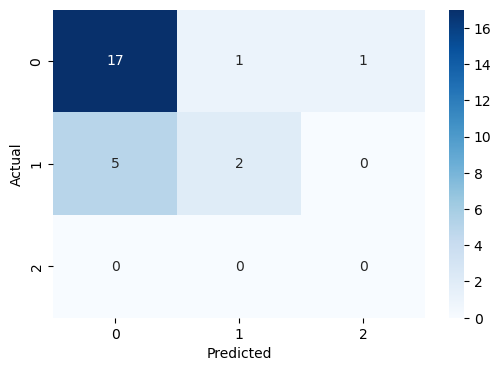

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("Predicted Performance Level:", le.inverse_transform(prediction))

Predicted Performance Level: ['Average']


In [26]:
import pickle
import os

# Create model directory
os.makedirs('../model', exist_ok=True)

# Save the trained model
with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)
print("✓ Model saved")

# Save the scaler
with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved")

# Save the label encoder
with open("../model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("✓ Label encoder saved")

# Save feature columns (this is crucial for prediction!)
feature_columns = list(X.columns)
with open("../model/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)
print("✓ Feature columns saved")
print(f"\nTotal features: {len(feature_columns)}")
print(f"Features: {feature_columns}")

✓ Model saved
✓ Scaler saved
✓ Label encoder saved
✓ Feature columns saved

Total features: 281
Features: ['Motivation_Level', 'Stress_Level', 'Confidence_Level', 'Enter Your Name_Abhilash S ', 'Enter Your Name_Abhishek', 'Enter Your Name_Abhishek Kumar', 'Enter Your Name_Abijith', 'Enter Your Name_Akanksha ', 'Enter Your Name_Akanksha Son Of Suresh Shetty', 'Enter Your Name_Akshara ', 'Enter Your Name_Akshath Shetty ', 'Enter Your Name_Akshatha ', 'Enter Your Name_Akshayan', 'Enter Your Name_Ameesha ', 'Enter Your Name_Ananya ', 'Enter Your Name_Anush', 'Enter Your Name_Anusha M ', 'Enter Your Name_Ashika ', 'Enter Your Name_Ashwath Shetty K ', 'Enter Your Name_Ashwija ', 'Enter Your Name_Ashwini N K ', 'Enter Your Name_Ayush ', 'Enter Your Name_Bhagyashri ', 'Enter Your Name_Bhavish B', 'Enter Your Name_Bhoomika V ', 'Enter Your Name_Bindu', 'Enter Your Name_Brijesh ', 'Enter Your Name_Carol Lobo ', 'Enter Your Name_Chaithanya', 'Enter Your Name_Darshan', 'Enter Your Name_Deeksha ', 